In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ricardofernandes99/kkllk/Dataset-iGov.csv


# Importing the Data

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ricardofernandes99/kkllk/Dataset-iGov.csv')
df.head()

,id_registo,data_registo,unidade_organizacional,tipo_servico,indicador_si,taxa_resolucao,tempo_resposta,satisfacao_cidadao,volume_interacoes,canal_utilizado,taxa_abandono,erros_tecnicos,transparencia,feedback_cidadao,segmentacao_utilizador,area_tematica,indicador_kpi
0,1,2024-04-12,Direcção De Serviços Financeiros,Telefone,83.02,87.37,36,3.8,368,Presencial,22.41,7,Sim,Processo Complicado,Empresa,Cultura,63.13
1,2,2024-12-14,Departamento De Inovação E Digitalização,Balcão Único,75.53,89.71,29,4.1,349,Email,14.87,1,Sim,Bom Serviço,Funcionário Público,Saúde,63.58
2,3,2024-09-27,Direcção De Recursos Humanos,Chatbot,85.73,75.96,38,3.3,398,Telefone,15.42,5,Não,Processo Complicado,Estudante,Inovação,73.64
3,4,2024-04-16,Departamento De Planeamento Estratégico,Email,78.33,73.82,57,3.4,74,Aplicacao_Movel,15.32,11,Sim,Processo Complicado,Funcionário Público,Digitalização,99.19
4,5,2024-03-12,Direcção De Recursos Humanos,Atendimento Presencial,81.82,70.41,97,4.7,487,Portal,7.47,4,Sim,Serviço Eficiente,Cidadão,Saúde,63.45


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_registo              200 non-null    int64  
 1   data_registo            200 non-null    object 
 2   unidade_organizacional  200 non-null    object 
 3   tipo_servico            200 non-null    object 
 4   indicador_si            200 non-null    float64
 5   taxa_resolucao          200 non-null    float64
 6   tempo_resposta          200 non-null    int64  
 7   satisfacao_cidadao      200 non-null    float64
 8   volume_interacoes       200 non-null    int64  
 9   canal_utilizado         200 non-null    object 
 10  taxa_abandono           200 non-null    float64
 11  erros_tecnicos          200 non-null    int64  
 12  transparencia           200 non-null    object 
 13  feedback_cidadao        200 non-null    object 
 14  segmentacao_utilizador  200 non-null    ob

# Checking for Missing Data

In [5]:
df.isnull().sum()

id_registo                0
data_registo              0
unidade_organizacional    0
tipo_servico              0
indicador_si              0
taxa_resolucao            0
tempo_resposta            0
satisfacao_cidadao        0
volume_interacoes         0
canal_utilizado           0
taxa_abandono             0
erros_tecnicos            0
transparencia             0
feedback_cidadao          0
segmentacao_utilizador    0
area_tematica             0
indicador_kpi             0
dtype: int64

We don't have any null values so that is good. We can proceed further to visualize the relations between the columns of the dataset.

# Visualizing the Data

# Multiple Linear Regression Model

In [7]:
#Independent Variables
X = df.drop(['indicador_kpi', 'data_registo'], axis=1)
y = df['indicador_kpi']


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "unidade_organizacional",
    "tipo_servico",
    "canal_utilizado",
    "transparencia",
    "feedback_cidadao",
    "segmentacao_utilizador",
    "area_tematica"
]

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X = ct.fit_transform(X)

**Splitting the data into training and testing sets**

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/3, random_state = 42)

**Applying the Linear Regression model**

In [19]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

**The coefficients of the model**

In [20]:
regressor.coef_

array([-6.57945230e+00,  5.46431492e+00,  1.04396484e+00, -4.73811639e+00,
        5.87895218e+00, -2.43678731e+00, -3.63766048e+00,  5.00478454e+00,
       -9.24686913e-01, -5.28268877e+00, -3.58185162e+00,  4.87002470e+00,
        4.26437407e+00,  3.74075421e+00, -3.08592567e+00, -1.43554553e+00,
        1.98306294e+00, -8.87750567e-01,  1.29446977e+00, -1.71221457e-01,
       -7.83015152e-01, -3.36811943e+00,  3.36811943e+00, -4.69063385e+00,
       -1.62886581e+00, -5.93376457e+00,  9.44116582e+00, -5.13923642e+00,
        1.10492507e+00,  6.53290105e+00,  5.26785529e+00, -1.03689342e-01,
       -4.85065722e+00, -4.31332964e+00, -1.85567570e+00,  2.85004772e-01,
        3.26690981e+00,  2.26195809e-01,  2.39089495e+00, -6.71893754e+00,
       -3.72783477e-01,  3.69157204e+00,  1.99298396e-01,  5.57156682e+00,
        1.66311205e+00,  7.13131009e-02, -4.70571390e+00,  6.00572511e-01,
       -4.30682101e-03,  7.76595771e-02,  4.16167452e-02, -4.04557809e-02,
       -1.53938630e+00, -

**The intercept of the model**

In [21]:
regressor.intercept_

75.43885173511535

**Predicting the data using our model**

In [22]:
y_pred = regressor.predict(X_test)

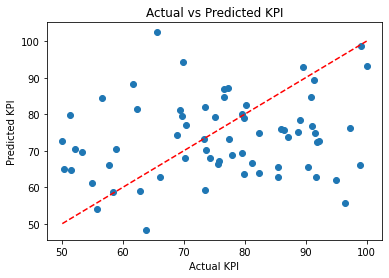

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual KPI")
plt.ylabel("Predicted KPI")
plt.title("Actual vs Predicted KPI")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

In [24]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    max_error,
    explained_variance_score
)


print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", np.sqrt(mse))

print("R2 Score:", r2_score(y_test, y_pred))

print("Explained Variance Score:", explained_variance_score(y_test, y_pred))

print("Median Absolute Error:", median_absolute_error(y_test, y_pred))

print("Max Error:", max_error(y_test, y_pred))

Mean Absolute Error (MAE): 13.003959308986465
Mean Squared Error (MSE): 259.71942625821
Root Mean Squared Error (RMSE): 16.115812925763628
R2 Score: -0.3457726317835046
Explained Variance Score: -0.31708781740088665
Median Absolute Error: 10.68296674746017
Max Error: 40.68272941316581
